# Import Libraries

In [3]:
pip install ipython-sql

Note: you may need to restart the kernel to use updated packages.


In [4]:
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [5]:
%sql sqlite:///superstore.db

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

# Understand data

In [6]:
import pandas as pd

df = pd.read_csv("superstore_data.csv")

df.to_sql("superstore", "sqlite:///superstore.db", index=False, if_exists='replace')

df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_id,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales
0,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      9800 non-null   object 
 1   order_date    9800 non-null   object 
 2   ship_date     9800 non-null   object 
 3   ship_mode     9800 non-null   object 
 4   customer_id   9800 non-null   object 
 5   segment       9800 non-null   object 
 6   country       9800 non-null   object 
 7   city          9800 non-null   object 
 8   state         9800 non-null   object 
 9   postal_code   9789 non-null   float64
 10  region        9800 non-null   object 
 11  product_id    9800 non-null   object 
 12  category      9800 non-null   object 
 13  sub_category  9800 non-null   object 
 14  product_name  9800 non-null   object 
 15  sales         9800 non-null   float64
dtypes: float64(2), object(14)
memory usage: 1.2+ MB


In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()

In [9]:
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      9800 non-null   object        
 1   order_date    9800 non-null   datetime64[ns]
 2   ship_date     9800 non-null   datetime64[ns]
 3   ship_mode     9800 non-null   object        
 4   customer_id   9800 non-null   object        
 5   segment       9800 non-null   object        
 6   country       9800 non-null   object        
 7   city          9800 non-null   object        
 8   state         9800 non-null   object        
 9   postal_code   9789 non-null   float64       
 10  region        9800 non-null   object        
 11  product_id    9800 non-null   object        
 12  category      9800 non-null   object        
 13  sub_category  9800 non-null   object        
 14  product_name  9800 non-null   object        
 15  sales         9800 non-null   float64 

#  Data Quality Assessment

## Check null values

In [11]:
df.isna().sum()

order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
segment          0
country          0
city             0
state            0
postal_code     11
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
year             0
month            0
day_of_week      0
dtype: int64

----------------------------------------

## Check duplicates

In [12]:
df.duplicated().sum()

1

In [13]:
df = df.drop_duplicates()

-------------------------------------------------------

## Drop unnecessary columns

In [14]:
# IDs: order_id, customer_id, product_id
# Dates: order_date, ship_date
# Geography: country, city, state, postal_code, region
# Product: category, sub_category, product_name
# Target: sales

In [15]:
# Pure identifiers (drop)
# order_id
# customer_id
# product_id

In [16]:
# High cardinality
# No generalizable pattern
# Will overfit models

In [17]:
# country  (always same → useless)
# postal_code  (too granular)
# city  (can be noisy)

# region  (best for aggregation)
# OR state (for want more detail)

In [18]:
x = df.drop(columns = ["customer_id", "product_id", "country", "postal_code", "city"])

------------------------

## Delivery time sanity

In [19]:
x['delivery_days'] = (x['ship_date'] - x['order_date']).dt.days

In [20]:
x['delivery_days'].describe()

count    9799.000000
mean        3.961118
std         1.749703
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: delivery_days, dtype: float64

--------------------------------------

## Check unique values for typos (categoricals)

In [21]:
x['ship_mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [22]:
x['region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [23]:
x['category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [24]:
x['sub_category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances',
       'Accessories', 'Envelopes', 'Fasteners', 'Paper', 'Supplies',
       'Machines', 'Copiers'], dtype=object)

--------------------------------------

## Ensure categories make business sense

In [25]:
x['segment'].value_counts()

Consumer       5101
Corporate      2953
Home Office    1745
Name: segment, dtype: int64

--------------------------------------------

# Descriptive Statistics

## Checking sales for outliers 

In [26]:
x['sales'].describe()

count     9799.000000
mean       230.763895
std        626.683644
min          0.444000
25%         17.248000
50%         54.480000
75%        210.572000
max      22638.480000
Name: sales, dtype: float64

In [27]:
Q1 = x['sales'].quantile(0.25)
Q3 = x['sales'].quantile(0.75)
IQR = Q3 - Q1

outliers = x[(x['sales'] < Q1 - 1.5*IQR) | (x['sales'] > Q3 + 1.5*IQR)]

In [84]:
outliers.head(10)

,order_id,order_date,ship_date,ship_mode,segment,state,region,category,sub_category,product_name,sales,year,month,day_of_week,delivery_days
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,Consumer,Kentucky,South,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,Wednesday,3
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,Consumer,Florida,South,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,Tuesday,7
7,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,Consumer,California,West,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015,June,Tuesday,5
10,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,Consumer,California,West,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,2015,June,Tuesday,5
11,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,Consumer,California,West,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,2015,June,Tuesday,5
16,CA-2015-105893,2015-11-11,2015-11-18,Standard Class,Consumer,Wisconsin,Central,Office Supplies,Storage,"Stur-D-Stor Shelving, Vertical 5-Shelf: 72""H x...",665.8800,2015,November,Wednesday,7
24,CA-2016-106320,2016-09-25,2016-09-30,Standard Class,Consumer,Utah,West,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,2016,September,Sunday,5
27,US-2016-150630,2016-09-17,2016-09-21,Standard Class,Consumer,Pennsylvania,East,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,2016,September,Saturday,4
35,CA-2017-117590,2017-12-08,2017-12-10,First Class,Corporate,Texas,Central,Technology,Phones,GE 30524EE4,1097.5440,2017,December,Friday,2
38,CA-2016-117415,2016-12-27,2016-12-31,Standard Class,Home Office,Texas,Central,Furniture,Bookcases,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",532.3992,2016,December,Tuesday,4


In [85]:
# x_cleaned = x.drop(outliers.index)

In [86]:
# 9799 - 1145 == 8654

---------------------------------------

## Which days of the week gets the most orders each month of each year?

### 2015

In [31]:
top1_2015 = (
    x[x['year'] == 2015]  # filter year
    .groupby(['month', 'day_of_week'])['order_id']
    .nunique()  # count unique orders
    .reset_index(name='order_count')
    .sort_values(['month', 'order_count'], ascending=[True, False])
    .groupby('month')
    .head(1)
)
top1_2015

,month,day_of_week,order_count
1,April,Saturday,13
7,August,Saturday,16
15,December,Sunday,29
25,February,Wednesday,6
31,January,Tuesday,12
35,July,Sunday,17
43,June,Tuesday,17
49,March,Tuesday,19
53,May,Saturday,14
64,November,Wednesday,29


### 2016

In [32]:
top1_2016 = (
    x[x['year'] == 2016]  # filter year
    .groupby(['month', 'day_of_week'])['order_id']
    .nunique()  # count unique orders
    .reset_index(name='order_count')
    .sort_values(['month', 'order_count'], ascending=[True, False])
    .groupby('month')
    .head(1)
)
top1_2016

,month,day_of_week,order_count
1,April,Monday,16
10,August,Sunday,15
19,December,Tuesday,34
22,February,Saturday,9
29,January,Sunday,8
35,July,Saturday,18
41,June,Saturday,14
50,March,Tuesday,20
57,May,Tuesday,16
64,November,Tuesday,36


### 2017

In [33]:
top1_2017 = (
    x[x['year'] == 2017]  # filter year
    .groupby(['month', 'day_of_week'])['order_id']
    .nunique()  # count unique orders
    .reset_index(name='order_count')
    .sort_values(['month', 'order_count'], ascending=[True, False])
    .groupby('month')
    .head(1)
)
top1_2017

,month,day_of_week,order_count
2,April,Saturday,24
12,August,Tuesday,22
14,December,Friday,37
26,February,Tuesday,11
30,January,Sunday,13
34,July,Friday,24
42,June,Monday,22
48,March,Friday,20
60,May,Tuesday,29
62,November,Friday,38


### 2018

In [34]:
top1_2018 = (
    x[x['year'] == 2018]  # filter year
    .groupby(['month', 'day_of_week'])['order_id']
    .nunique()  # count unique orders
    .reset_index(name='order_count')
    .sort_values(['month', 'order_count'], ascending=[True, False])
    .groupby('month')
    .head(1)
)
top1_2018

,month,day_of_week,order_count
1,April,Monday,33
7,August,Friday,22
17,December,Sunday,47
23,February,Saturday,12
28,January,Monday,15
38,July,Tuesday,27
40,June,Friday,28
49,March,Saturday,26
56,May,Saturday,23
61,November,Friday,51


------------------------------------------

## Which months gets the most orders each year?

In [35]:
orders_per_month = (
    x.groupby(['year', 'month'])['order_id']
     .nunique()
     .reset_index(name='order_count')
     .sort_values(['year', 'order_count'], ascending=[True, False])
)

In [37]:
orders_per_month[orders_per_month['year'] == 2015].head(3)

,year,month,order_count
9,2015,November,145
2,2015,December,139
11,2015,September,129


In [38]:
orders_per_month[orders_per_month['year'] == 2016].head(3)

,year,month,order_count
14,2016,December,159
21,2016,November,157
23,2016,September,137


In [39]:
orders_per_month[orders_per_month['year'] == 2017].head(3)

,year,month,order_count
35,2017,September,186
33,2017,November,182
26,2017,December,172


In [40]:
orders_per_month[orders_per_month['year'] == 2018].head(3)

,year,month,order_count
45,2018,November,259
38,2018,December,223
47,2018,September,222


## How much did sales increase each year in percentage?

In [42]:
sales_per_year = x.groupby('year')['sales'].sum()

In [90]:
sales_per_year

year
2015    479574.8361
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: sales, dtype: float64

In [88]:
sales_growth_pct = sales_per_year.pct_change() * 100
sales_growth = pd.DataFrame(sales_growth_pct)
sales_growth

,sales
year,
2015,NaN
2016,-4.199309
2017,30.636812
2018,20.303396


## What type of customers orders the most?

In [44]:
segment_count = x.groupby('segment')['order_id'].nunique()
segment_count

segment
Consumer       2537
Corporate      1491
Home Office     894
Name: order_id, dtype: int64

In [45]:
sales_per_segment = x.groupby('segment')['sales'].sum()
sales_per_segment.apply(lambda x: f"{x:,.0f}")

segment
Consumer       1,148,061
Corporate        688,494
Home Office      424,701
Name: sales, dtype: object

#### Average Order Value (AOV) (aov = sales / orders)

##### Consumer →  452
##### Corporate →  462
##### Home Office →  475

## Which ship mode is the most used?

1. Standard Class
Slowest option
Usually 3–5 days
Lowest cost

--- Most commonly used (default choice)

Interpretation:

Customers are not in a rush and prefer cheaper shipping.

2. Second Class
Medium speed
Typically 2–3 days
Moderate cost

Interpretation:

Customers want faster delivery but still care about cost.

3. First Class
Faster shipping
Usually 1–2 days
Higher cost

Interpretation:

Customers prioritize speed over price.

4. Same Day
Fastest option (same day delivery)
Most expensive
Least frequently used

Interpretation:

Urgent purchases or high-priority needs.

In [46]:
ship_mode_summary = (
    x.groupby('ship_mode')
     .agg(
         orders_count=('order_id', 'nunique'),
         total_sales=('sales', 'sum'),
         avg_delivery_days=('delivery_days', 'mean')
     )
     .reset_index()
     .sort_values('total_sales', ascending = False)
)
ship_mode_summary["total_sales"] = ship_mode_summary["total_sales"].apply(lambda x: f"{x:,.0f}")
ship_mode_summary

,ship_mode,orders_count,total_sales,avg_delivery_days
3,Standard Class,2945,"1,340,550",5.008535
2,Second Class,944,"449,914",3.249211
0,First Class,772,"345,572",2.179214
1,Same Day,261,"125,219",0.044610


## From where do the store get the most orders

### Region and State 

In [102]:
# orders_per_region = x.groupby('region')['order_id'].nunique()
# orders_per_region.sort_values(ascending = False)

In [101]:
# orders_per_westcity = x[x['region'] == 'West'].groupby('state')['order_id'].nunique()
# orders_per_westcity.sort_values(ascending = False)

In [103]:
sales_per_region = x.groupby('region')['sales'].sum()
sales_per_region.sort_values(ascending = False)

region
West       710219.6845
East       669237.3540
Central    492646.9132
South      389151.4590
Name: sales, dtype: float64

In [91]:
sales_per_westcity = x[x['region'] == 'West'].groupby('state')['sales'].nunique()
sales_per_westcity.sort_values(ascending = False)

state
California    1500
Washington     459
Arizona        215
Colorado       176
Oregon         117
Utah            53
Nevada          39
New Mexico      37
Idaho           21
Montana         15
Wyoming          1
Name: sales, dtype: int64

■ West region leads activity, but a deeper dive reveals a strong concentration in California.

■ This indicates both a high-performing core market and a potential over-reliance risk, while other states represent untapped growth opportunities.ities.

### Category

In [54]:
orders_per_category = x.groupby('category')['order_id'].nunique()
orders_per_category.sort_values(ascending = False)

category
Office Supplies    3676
Furniture          1727
Technology         1519
Name: order_id, dtype: int64

In [55]:
sales_per_category = x.groupby('category')['sales'].sum()
# .apply(lambda x: f"{x:,.2f}")
sales_per_category.sort_values(ascending = False)

category
Technology         827455.8730
Furniture          728377.2037
Office Supplies    705422.3340
Name: sales, dtype: float64

In [57]:
AOV_per_category = sales_per_category / orders_per_category
AOV_per_category.sort_values(ascending = False)

category
Technology         544.737244
Furniture          421.758659
Office Supplies    191.899438
dtype: float64

### Subcategory

In [96]:
sales_per_subcategory = (
    x.groupby("sub_category", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
      .head(10)
)

In [62]:
%%sql
SELECT DISTINCT sub_category AS 'Tech' from superstore
WHERE category = "Technology";

 * sqlite:///superstore.db
Done.


Tech
Phones
Accessories
Machines
Copiers


In [63]:
%%sql 
SELECT DISTINCT sub_category AS 'Office Supplies'
FROM superstore
WHERE category = 'Office Supplies';

 * sqlite:///superstore.db
Done.


Office Supplies
Labels
Storage
Art
Binders
Appliances
Envelopes
Fasteners
Paper
Supplies


In [64]:
%%sql
SELECT DISTINCT sub_category AS "Furniture"
FROM superstore
WHERE category = 'Furniture';

 * sqlite:///superstore.db
Done.


Furniture
Bookcases
Chairs
Tables
Furnishings


-----------------------------------

# Univariate Analysis

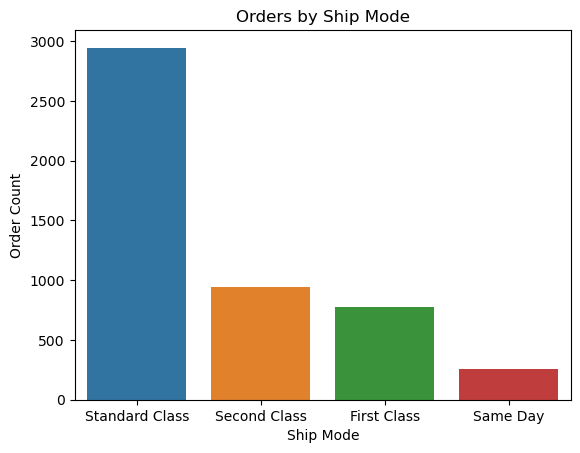

In [111]:
ship_mode = (
    x.groupby("ship_mode", as_index=False)["order_id"]
      .nunique()
      .sort_values(by="order_id", ascending=False)
      .head(10)
)

sns.barplot(data=ship_mode, x="ship_mode", y="order_id")
plt.title("Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Order Count")
plt.show()

<Axes: title={'center': 'AOV by Category'}, xlabel='category'>

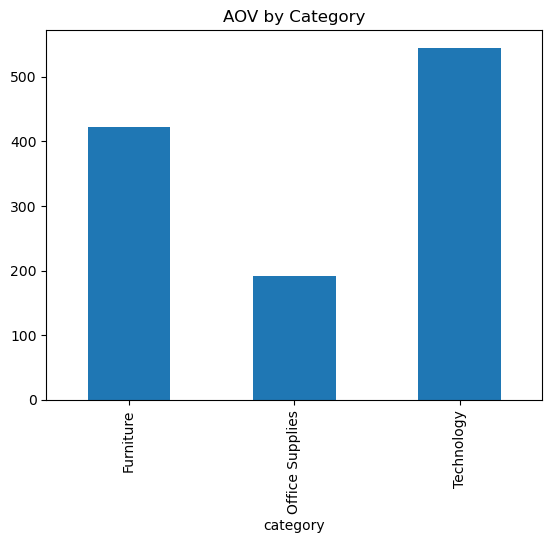

In [107]:
AOV_per_category.plot(kind="bar",
    x="category",
    y="Average order value",
    title="AOV by Category")

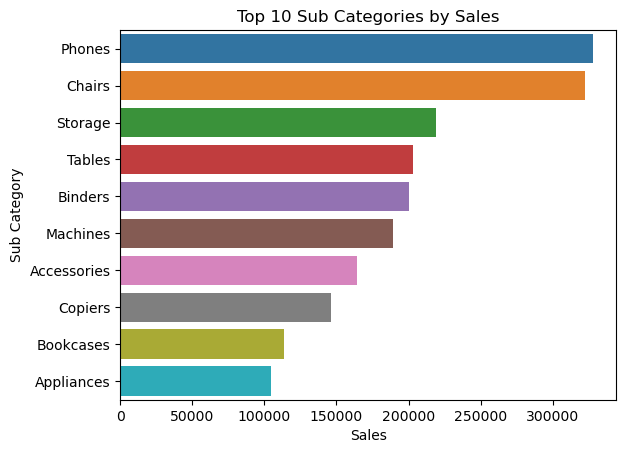

In [97]:
sns.barplot(data=sales_per_subcategory, x="sales", y="sub_category")
plt.title("Top 10 Sub Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("Sub Category")
plt.show()

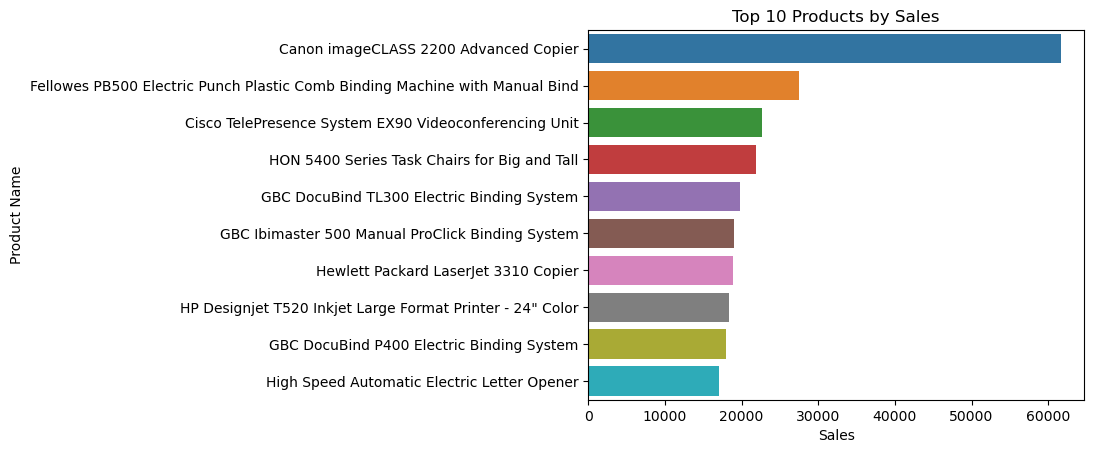

In [94]:
top_products = (
    x.groupby("product_name", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
      .head(10)
)

sns.barplot(data=top_products, x="sales", y="product_name")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()

## Which year had the most orders and highest sales?

In [67]:
x['Month'] = x['order_date'].dt.month

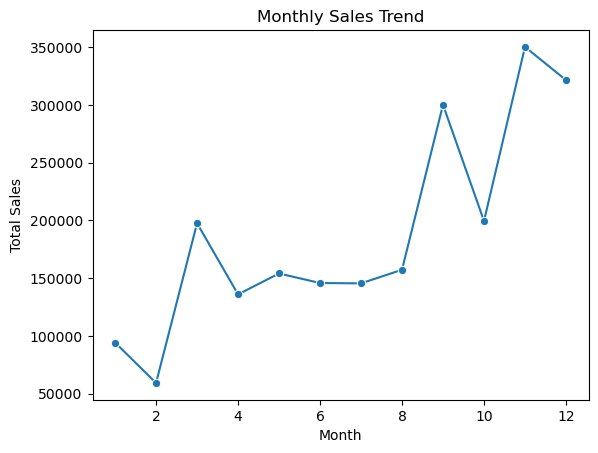

In [70]:
monthly_sales = (
    x.groupby("Month", as_index=False)["sales"]
      .sum()
      .sort_values("Month")
)

sns.lineplot(data=monthly_sales, x="Month", y="sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## Check distribution of sales 

<Axes: >

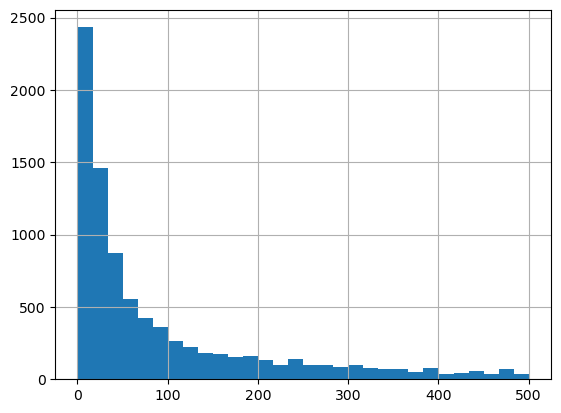

In [71]:
x[x['sales'] < 500]['sales'].hist(bins=30)

# Feature engineering Insights

## What is the delivery average time?

In [ ]:
x['delivery_days'].mean()

■ On average, delivery takes approximately 4 days.